# `SoftHarmonic` bond & `SoftHarmonicAngle` — emergent behaviour

These forces are **harmonic near equilibrium but saturate in the tail** (chosen per
type via `tail`), so `k` keeps its usual meaning near the minimum. With the signed
deviation $x = r - r_0$ (bond) or $x = \theta - t_0$ (angle) and crossover $x_c$:

$$U_{\mathrm{linear}}(x)=\begin{cases}\tfrac12 k x^2 & |x|\le x_c\\[2pt]
k x_c |x|-\tfrac12 k x_c^2 & |x|>x_c\end{cases}
\qquad
U_{\mathrm{flat}}(x)=\begin{cases}\tfrac12 k x^2\bigl(1-s^2+\tfrac13 s^4\bigr),\ s=x/x_c & |x|\le x_c\\[2pt]
\tfrac16 k x_c^2 & |x|>x_c\end{cases}$$

| `tail` | force/torque beyond `x_c` | behaviour |
|--------|---------------------------|-----------|
| `"linear"` (Huber) | **constant** $k\,x_c$ (capped) | ductile / stable |
| `"flat"` | decays smoothly to **zero** at $x_c$ | breakable / a free hinge |

The potential shapes are in [`energy_landscapes.ipynb`](energy_landscapes.ipynb).
This notebook shows three things you **cannot read off the potential** — each
measured from a real simulation and contrasted with the standard harmonic force:

1. **Kinkable filament** (flat angle) — same local stiffness, but thermal *kinks*
   appear: a non-Gaussian bending distribution and a much shorter persistence length.
2. **Breakable vs ductile bond** (flat vs linear) — a pulled chain fails *brittly*
   (flat) or *yields* ductilely (linear), while harmonic just stretches.
3. **Time-step stability** (linear bond) — the force cap removes the stiff timescale
   of taut bonds, so integration survives a much larger `dt`.

Everything above the divider is execution; every figure is below it.

In [1]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt

import hoomd
import hoomd.md
import gsd.hoomd

from hoomd import align_angle
from polykit.generators.initial_conformations import create_constrained_random_walk

import demo_viz as v   # viz/analysis only; used only below the divider

try:
    device = hoomd.device.GPU()
except Exception:
    device = hoomd.device.CPU()
print("HOOMD", hoomd.version.version, "| device:", type(device).__name__,
      "| precision", hoomd.version.floating_point_precision)

HOOMD 6.1.1 | device: GPU | precision (64, 32)


## 1. Kinkable filament (flat angle)

A long semiflexible chain, started from a worm-like fold and run with a **harmonic**
angle vs a **flat-tail** angle of the *same* stiffness `k` (`t0 = π`). Near
equilibrium they are identical (so the harmonic chain recovers `Lp ≈ k`), but bending
past `x_c` costs the flat tail only `k·x_c²/6`, so **rare thermal kinks** become
accessible. We build one initial configuration and run both angle forces from it.

In [2]:
# --- kink filament parameters ---
N_KINK    = 3000        # beads in the semiflexible chain
PERSIST   = 0.10        # fixed turn per step of the initial worm-like fold
K_BOND    = 300.0       # harmonic bond stiffness (backbone connectivity)
K_ANGLE   = 180.0       # bending stiffness -- tuned so kinks stay rare (a few %)
XC        = 0.5         # angle crossover x_c (rad): bends past this saturate (flat)
KT        = 1.0
DT        = 0.005
N_WARMUP  = 10_000      # gentle dt-ramp warmup to relax the sharp initial folds
N_EQUIL   = 60_000      # equilibration at the production dt
NUM_BLOCKS, BLOCK = 40, 1000     # production, streamed frame every BLOCK steps

OUT_DIR = pathlib.Path("./soft_harmonic_traj")
OUT_DIR.mkdir(exist_ok=True)
KINK_INIT = OUT_DIR / "kink_init.gsd"

# initial conformation: a persistent (worm-like) walk -- folded but locally
# near-straight, so both chains start close to the stiff harmonic equilibrium.
np.random.seed(0)
pos = create_constrained_random_walk(N_KINK, lambda x: True, step_size=1.0, polar_fixed=PERSIST)
pos = np.asarray(pos, dtype=float)
pos -= pos.mean(axis=0)
L = 2.0 * float(np.abs(pos).max()) + 30.0

# the configuration is a gsd.hoomd.Frame (particles, bonds, angles, box)
frame = gsd.hoomd.Frame()
frame.configuration.box = [L, L, L, 0, 0, 0]
frame.particles.N = N_KINK
frame.particles.types = ["A"]
frame.particles.typeid = np.zeros(N_KINK, dtype=int)
frame.particles.position = pos
frame.particles.mass = np.ones(N_KINK)
# backbone bonds (i, i+1)
frame.bonds.N = N_KINK - 1
frame.bonds.types = ["A-A"]
frame.bonds.typeid = np.zeros(N_KINK - 1, dtype=int)
frame.bonds.group = np.column_stack([np.arange(N_KINK - 1), np.arange(1, N_KINK)])
# bending angles (i-1, i, i+1)
frame.angles.N = N_KINK - 2
frame.angles.types = ["A-A-A"]
frame.angles.typeid = np.zeros(N_KINK - 2, dtype=int)
frame.angles.group = np.column_stack([np.arange(N_KINK - 2), np.arange(1, N_KINK - 1), np.arange(2, N_KINK)])

with gsd.hoomd.open(name=str(KINK_INIT), mode="w") as f:
    f.append(frame)
print(f"{N_KINK} beads, {N_KINK - 1} bonds, {N_KINK - 2} angles; box L = {L:.0f}; wrote {KINK_INIT}")

3000 beads, 2999 bonds, 2998 angles; box L = 876; wrote soft_harmonic_traj/kink_init.gsd


Run both angle forces from the same `init.gsd`, streaming each trajectory:

In [3]:
def make_angle(cls, **params):
    force = cls()
    force.params["A-A-A"] = params
    return force


def run_kink(angle_force_factory, label):
    # build a chain simulation with the given angle force, equilibrate, and stream
    # the production trajectory to {label}.gsd for analysis below the divider
    sim = hoomd.Simulation(device=device, seed=7)
    sim.create_state_from_gsd(filename=str(KINK_INIT))
    sim.state.thermalize_particle_momenta(filter=hoomd.filter.All(), kT=KT)

    bond = hoomd.md.bond.Harmonic()
    bond.params["A-A"] = dict(k=K_BOND, r0=1.0)
    angle = angle_force_factory()

    langevin = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=KT)
    integrator = hoomd.md.Integrator(dt=DT, methods=[langevin], forces=[bond, angle])
    sim.operations.integrator = integrator

    thermo = hoomd.md.compute.ThermodynamicQuantities(filter=hoomd.filter.All())
    sim.operations.computes.append(thermo)

    traj_path = OUT_DIR / f"{label}.gsd"
    writer = hoomd.write.GSD(filename=str(traj_path), mode="wb",
                             trigger=hoomd.trigger.Periodic(BLOCK), dynamic=["property"])
    sim.operations.writers.append(writer)

    # dt-ramp warmup relaxes the sharp initial folds, then equilibrate at DT
    for warm_dt in (1e-4, 1e-3):
        integrator.dt = warm_dt
        sim.run(N_WARMUP // 2)
    integrator.dt = DT
    sim.run(N_EQUIL)

    # production: stream the trajectory, logging thermo every few blocks
    for i in range(NUM_BLOCKS):
        sim.run(BLOCK)
        if i == 0 or (i + 1) % 10 == 0:
            print(f"[{label:>8s}] block {i + 1:2d}/{NUM_BLOCKS}  E_P/N = {thermo.potential_energy / N_KINK:7.3f}")
    writer.flush()
    assert np.isfinite(angle.energy) and abs(angle.energy) > 0     # the angle force is exercised
    return traj_path


TRAJ_HARMONIC = run_kink(lambda: make_angle(hoomd.md.angle.Harmonic, k=K_ANGLE, t0=np.pi), "harmonic")
TRAJ_FLAT = run_kink(lambda: make_angle(align_angle.SoftHarmonicAngle, k=K_ANGLE, t0=np.pi, x_c=XC, tail="flat"), "flat")

[harmonic] block  1/40  E_P/N =   1.500


[harmonic] block 10/40  E_P/N =   1.495


[harmonic] block 20/40  E_P/N =   1.506


[harmonic] block 30/40  E_P/N =   1.500


[harmonic] block 40/40  E_P/N =   1.521


[    flat] block  1/40  E_P/N =   1.857
[    flat] block 10/40  E_P/N =   1.862


[    flat] block 20/40  E_P/N =   1.841
[    flat] block 30/40  E_P/N =   1.846


[    flat] block 40/40  E_P/N =   1.916


## 2. Breakable vs ductile bond (flat vs linear)

Pull a chain by its ends under **displacement control** — fix both ends at a
separation `d`, ramp it, and measure the tension the chain sustains. Unlike a
force-controlled pull, this captures what happens *after* the peak: **harmonic**
rises without bound (elastic); **linear** plateaus at the yield `k·x_c` (ductile);
**flat** peaks then **collapses to zero** as the strain localizes into one bond that
ruptures past `x_c` (brittle). This is a quasi-static measurement sweep, so it builds
a small in-memory snapshot per point rather than streaming a trajectory.

In [4]:
# --- rupture parameters ---
N_PULL   = 80          # beads in the pulled chain
K_PULL   = 40.0        # bond stiffness
XC_PULL  = 0.5         # bond crossover x_c
KT_PULL  = 0.1         # low temperature -> clean force-extension curves
STRAINS  = np.linspace(0.0, 1.1, 45)     # mean bond strain x = r - r0


def make_bond(cls, **params):
    force = cls()
    force.params["A-A"] = params
    return force


def tension_curve(bond_factory):
    # a chain along x with both ends (0, N-1) fixed; ramp the end separation and
    # measure the tension the chain holds (x-force on the anchor bond)
    L = 1.0e5
    snap = hoomd.Snapshot(device.communicator)
    if snap.communicator.rank == 0:
        snap.configuration.box = [L, L, L, 0, 0, 0]
        snap.particles.N = N_PULL
        snap.particles.types = ["A"]
        snap.particles.mass[:] = 1.0
        snap.particles.position[:] = np.column_stack([np.arange(N_PULL) * 1.0, np.zeros(N_PULL), np.zeros(N_PULL)])
        snap.bonds.N = N_PULL - 1
        snap.bonds.types = ["A-A"]
        snap.bonds.group[:] = np.column_stack([np.arange(N_PULL - 1), np.arange(1, N_PULL)])
    sim = hoomd.Simulation(device=device, seed=3)
    sim.create_state_from_snapshot(snap)

    bond = bond_factory()
    mobile = hoomd.filter.SetDifference(hoomd.filter.All(), hoomd.filter.Tags([0, N_PULL - 1]))
    langevin = hoomd.md.methods.Langevin(filter=mobile, kT=KT_PULL)
    sim.operations.integrator = hoomd.md.Integrator(dt=0.005, methods=[langevin], forces=[bond])
    sim.run(0)

    tension = []
    for x in STRAINS:
        # place the ends d apart with the interior spread uniformly, then relax
        d = (N_PULL - 1) * (1.0 + x)
        state = sim.state.get_snapshot()
        state.particles.position[:, 0] = np.linspace(0.0, d, N_PULL)
        state.particles.position[:, 1] = 0.0
        state.particles.position[:, 2] = 0.0
        sim.state.set_snapshot(state)
        sim.run(3000)
        samples = []
        for _ in range(25):
            sim.run(100)
            samples.append(abs(float(np.asarray(bond.forces)[0, 0])))
        tension.append(np.mean(samples))
    return np.array(tension)


T_harmonic = tension_curve(lambda: make_bond(hoomd.md.bond.Harmonic, k=K_PULL, r0=1.0))
T_linear = tension_curve(lambda: make_bond(align_angle.SoftHarmonic, k=K_PULL, r0=1.0, x_c=XC_PULL, tail="linear"))
T_flat = tension_curve(lambda: make_bond(align_angle.SoftHarmonic, k=K_PULL, r0=1.0, x_c=XC_PULL, tail="flat"))
print(f"[rupture] linear plateau ~ k*x_c = {K_PULL * XC_PULL:.0f};  "
      f"flat peaks at {T_flat.max():.1f} then ruptures to ~0")

[rupture] linear plateau ~ k*x_c = 20;  flat peaks at 2.1 then ruptures to ~0


## 3. Time-step stability (linear bond)

A plain harmonic bond is linear, so integration is stable only for `dt < ~2/√k`
however far it is stretched. The **linear** tail is *flat* beyond `x_c` (zero
curvature), so bonds held in the tail impose **no** stiff timescale. We hold a chain
taut (both ends fixed at 60 % strain, every bond in the tail) and sweep `dt`.

In [5]:
# --- stability parameters ---
N_TAUT   = 150         # beads in the taut chain
K_TAUT   = 200.0       # bond stiffness
XC_TAUT  = 0.3         # bond crossover x_c
STRAIN   = 0.6         # every bond stretched to 60% strain (in the tail)
DT_SWEEP = [0.01, 0.02, 0.04, 0.06, 0.08, 0.1, 0.14, 0.18]
N_STEPS  = 8000        # survival horizon per dt


def steps_survived(bond_factory, dt):
    # a taut chain (both ends fixed); integrate at dt and report how many steps it
    # survives before the kinetic energy / positions blow up (capped at N_STEPS)
    try:
        L = 400.0
        d = (N_TAUT - 1) * (1.0 + STRAIN)
        snap = hoomd.Snapshot(device.communicator)
        if snap.communicator.rank == 0:
            snap.configuration.box = [L, L, L, 0, 0, 0]
            snap.particles.N = N_TAUT
            snap.particles.types = ["A"]
            snap.particles.mass[:] = 1.0
            snap.particles.position[:] = np.column_stack([np.linspace(-d / 2, d / 2, N_TAUT), np.zeros(N_TAUT), np.zeros(N_TAUT)])
            snap.bonds.N = N_TAUT - 1
            snap.bonds.types = ["A-A"]
            snap.bonds.group[:] = np.column_stack([np.arange(N_TAUT - 1), np.arange(1, N_TAUT)])
        sim = hoomd.Simulation(device=device, seed=123)
        sim.create_state_from_snapshot(snap)

        mobile = hoomd.filter.SetDifference(hoomd.filter.All(), hoomd.filter.Tags([0, N_TAUT - 1]))
        langevin = hoomd.md.methods.Langevin(filter=mobile, kT=1.0)
        sim.operations.integrator = hoomd.md.Integrator(dt=dt, methods=[langevin], forces=[bond_factory()])
        thermo = hoomd.md.compute.ThermodynamicQuantities(filter=mobile)
        sim.operations.computes.append(thermo)

        done = 0
        for _ in range(N_STEPS // 1000):
            sim.run(1000)
            done += 1000
            positions = np.asarray(sim.state.get_snapshot().particles.position)
            blew_up = not (np.isfinite(thermo.kinetic_energy) and thermo.kinetic_energy / N_TAUT < 1e6
                           and np.all(np.isfinite(positions)))
            if blew_up:
                return done
        return N_STEPS
    except Exception:
        return 0


surv_harmonic = [steps_survived(lambda: make_bond(hoomd.md.bond.Harmonic, k=K_TAUT, r0=1.0), dt) for dt in DT_SWEEP]
surv_linear = [steps_survived(lambda: make_bond(align_angle.SoftHarmonic, k=K_TAUT, r0=1.0, x_c=XC_TAUT, tail="linear"), dt) for dt in DT_SWEEP]
max_dt_harmonic = max([dt for dt, s in zip(DT_SWEEP, surv_harmonic) if s == N_STEPS], default=0)
max_dt_linear = max([dt for dt, s in zip(DT_SWEEP, surv_linear) if s == N_STEPS], default=0)
print(f"[stability] max stable dt:  harmonic = {max_dt_harmonic},  SoftHarmonic linear = {max_dt_linear}"
      + (f"  ({max_dt_linear / max_dt_harmonic:.0f}x)" if max_dt_harmonic else ""))

[stability] max stable dt:  harmonic = 0.06,  SoftHarmonic linear = 0.18  (3x)


# ═══════ EXECUTION COMPLETE — VISUALIZATION & ANALYSIS BELOW ═══════

## Results

### 1 — Kinkable filament

Reading each kink trajectory back, we pool the bending angles over all frames to get
`P(β)` and the persistence length `Lp = -b / ln⟨cos β⟩`, and take the final frame for
the conformation.

In [6]:
def bending(p):
    # bending angle at each interior joint of a chain
    u = p[1:] - p[:-1]
    u /= np.linalg.norm(u, axis=1, keepdims=True)
    return np.arccos(np.einsum("ij,ij->i", u[:-1], u[1:]).clip(-1, 1))


def kink_stats(traj_path):
    # pooled bending angles over all frames, Lp, and the final frame's per-joint
    # profile + unwrapped positions
    traj = gsd.hoomd.open(name=str(traj_path))
    betas = [bending(v.unwrap(fr.particles.position, fr.particles.image, fr.configuration.box)) for fr in traj]
    last = gsd.hoomd.open(name=str(traj_path))[-1]
    pos_last = v.unwrap(last.particles.position, last.particles.image, last.configuration.box)
    betas = np.concatenate(betas)
    Lp = -1.0 / np.log(np.cos(betas).mean())          # bond length b = 1
    return betas, Lp, bending(pos_last), pos_last


beta_h, Lp_h, prof_h, pos_h = kink_stats(TRAJ_HARMONIC)
beta_f, Lp_f, prof_f, pos_f = kink_stats(TRAJ_FLAT)
print(f"harmonic Lp = {Lp_h:.0f} b ({np.mean(beta_h > XC):.1%} kinks);  "
      f"flat Lp = {Lp_f:.0f} b ({np.mean(beta_f > XC):.1%} kinks)")

# --- each plugin force produces its signature outcome ---
checks = [
    ("SoftHarmonicAngle: flat grows kinks, harmonic does not",
     np.mean(beta_f > XC) > 0.005 and np.mean(beta_h > XC) < 0.003),
    ("SoftHarmonicAngle: flat persistence length is much shorter",
     Lp_f < 0.5 * Lp_h),
    ("SoftHarmonic linear: ductile plateau near k*x_c",
     abs(T_linear[-8:].mean() - K_PULL * XC_PULL) < 0.25 * K_PULL * XC_PULL),
    ("SoftHarmonic flat: tension ruptures to ~zero",
     T_flat[-8:].mean() < 0.2 * K_PULL * XC_PULL),
    ("SoftHarmonic linear: larger stable dt than harmonic",
     max_dt_linear > max_dt_harmonic),
]
for name, ok in checks:
    print(f"[{'PASS' if ok else 'FAIL'}] {name}")
assert all(ok for _, ok in checks)

harmonic Lp = 180 b (0.0% kinks);  flat Lp = 44 b (2.4% kinks)
[PASS] SoftHarmonicAngle: flat grows kinks, harmonic does not
[PASS] SoftHarmonicAngle: flat persistence length is much shorter
[PASS] SoftHarmonic linear: ductile plateau near k*x_c
[PASS] SoftHarmonic flat: tension ruptures to ~zero
[PASS] SoftHarmonic linear: larger stable dt than harmonic


The conformations — a 2-D projection onto each chain's principal axes, backbone
coloured by local bending and joints past `x_c` marked in red:

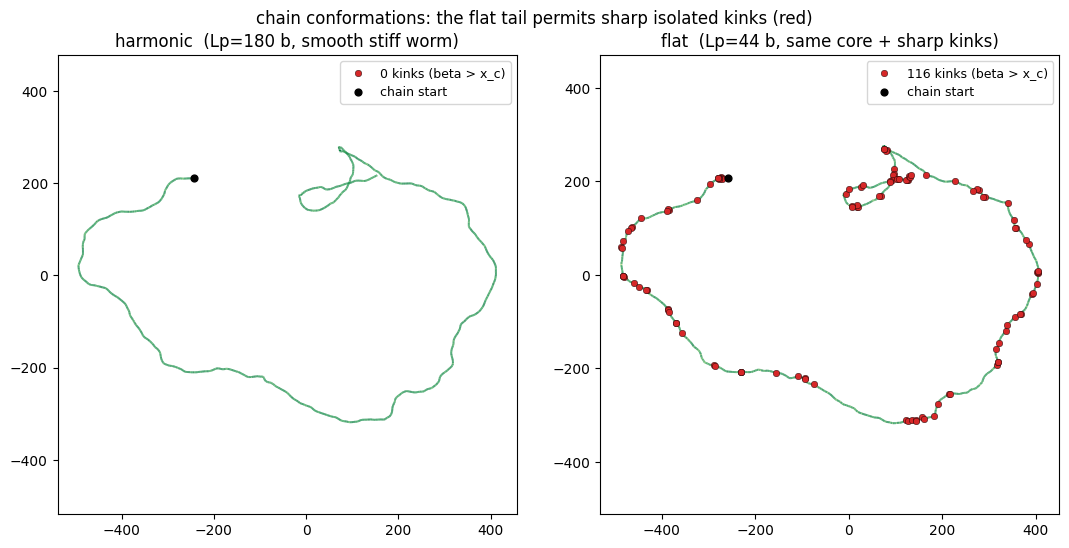

In [7]:
def project2d(p):
    c = p - p.mean(axis=0)
    _, _, Vt = np.linalg.svd(c, full_matrices=False)
    return c @ Vt[:2].T


def draw_chain(ax, p, prof, title):
    from matplotlib.collections import LineCollection
    q = project2d(p)
    seg = np.stack([q[:-1], q[1:]], axis=1)
    lc = LineCollection(seg, cmap="RdYlGn_r", norm=plt.Normalize(0, 1.0), lw=1.4)
    lc.set_array(np.concatenate([[0], prof]))
    ax.add_collection(lc)
    kb = np.where(prof > XC)[0] + 1
    ax.scatter(q[kb, 0], q[kb, 1], c="C3", s=22, edgecolors="k", linewidths=0.3,
               zorder=6, label=f"{len(kb)} kinks (beta > x_c)")
    ax.scatter(*q[0], c="k", s=24, zorder=7, label="chain start")
    ctr = 0.5 * (q.max(0) + q.min(0))
    rad = 0.55 * float(np.ptp(q, axis=0).max())
    ax.set_xlim(ctr[0] - rad, ctr[0] + rad)
    ax.set_ylim(ctr[1] - rad, ctr[1] + rad)
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=9)


fig, ax = plt.subplots(1, 2, figsize=(11, 5.4))
draw_chain(ax[0], pos_h, prof_h, f"harmonic  (Lp={Lp_h:.0f} b, smooth stiff worm)")
draw_chain(ax[1], pos_f, prof_f, f"flat  (Lp={Lp_f:.0f} b, same core + sharp kinks)")
fig.suptitle("chain conformations: the flat tail permits sharp isolated kinks (red)")
fig.tight_layout(); plt.show()

The bending-angle statistics behind the pictures:

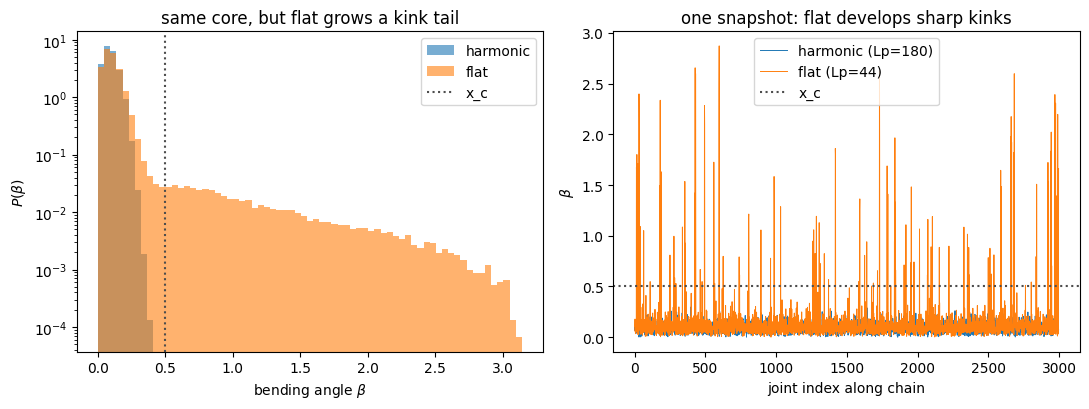

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
bins = np.linspace(0, np.pi, 70)
a1.hist(beta_h, bins=bins, density=True, alpha=0.6, label="harmonic")
a1.hist(beta_f, bins=bins, density=True, alpha=0.6, label="flat")
a1.axvline(XC, color="0.3", ls=":", label="x_c")
a1.set_yscale("log")
a1.set_xlabel(r"bending angle $\beta$"); a1.set_ylabel(r"$P(\beta)$")
a1.set_title("same core, but flat grows a kink tail"); a1.legend()
a2.plot(np.arange(len(prof_h)), prof_h, lw=0.7, label=f"harmonic (Lp={Lp_h:.0f})")
a2.plot(np.arange(len(prof_f)), prof_f, lw=0.7, label=f"flat (Lp={Lp_f:.0f})")
a2.axhline(XC, color="0.3", ls=":", label="x_c")
a2.set_xlabel("joint index along chain"); a2.set_ylabel(r"$\beta$")
a2.set_title("one snapshot: flat develops sharp kinks"); a2.legend()
fig.tight_layout(); plt.show()

### 2 — Breakable vs ductile bond (force–extension)

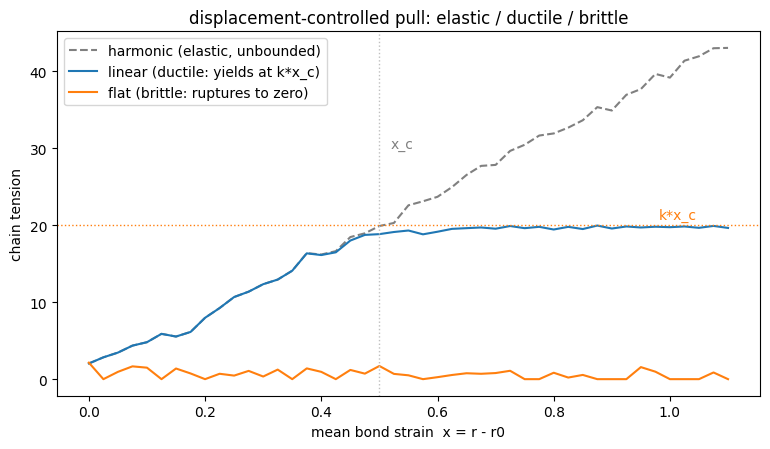

In [9]:
fig, ax = plt.subplots(figsize=(7.8, 4.6))
ax.plot(STRAINS, T_harmonic, "--", color="0.5", label="harmonic (elastic, unbounded)")
ax.plot(STRAINS, T_linear, label="linear (ductile: yields at k*x_c)")
ax.plot(STRAINS, T_flat, label="flat (brittle: ruptures to zero)")
ax.axhline(K_PULL * XC_PULL, color="C1", ls=":", lw=1)
ax.text(0.98, K_PULL * XC_PULL + 0.8, "k*x_c", color="C1")
ax.axvline(XC_PULL, color="0.75", ls=":", lw=1)
ax.text(XC_PULL + 0.02, 30, "x_c", color="0.5")
ax.set_xlabel("mean bond strain  x = r - r0"); ax.set_ylabel("chain tension")
ax.set_title("displacement-controlled pull: elastic / ductile / brittle"); ax.legend()
fig.tight_layout(); plt.show()

### 3 — Time-step stability

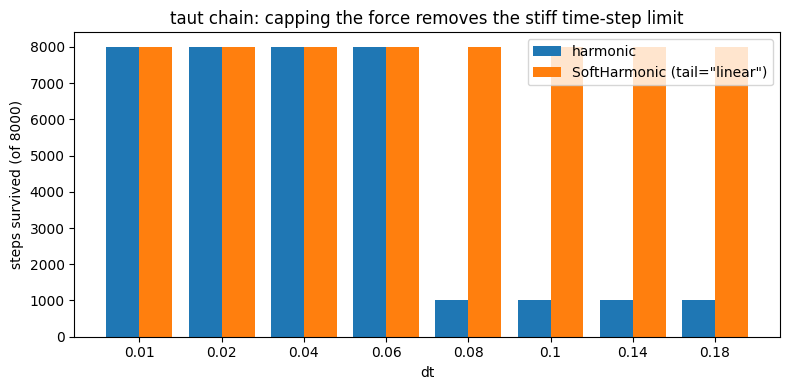

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
xpos = np.arange(len(DT_SWEEP))
w = 0.4
ax.bar(xpos - w / 2, surv_harmonic, w, label="harmonic")
ax.bar(xpos + w / 2, surv_linear, w, label='SoftHarmonic (tail="linear")')
ax.set_xticks(xpos)
ax.set_xticklabels([str(d) for d in DT_SWEEP])
ax.set_xlabel("dt"); ax.set_ylabel(f"steps survived (of {N_STEPS})")
ax.set_title("taut chain: capping the force removes the stiff time-step limit"); ax.legend()
fig.tight_layout(); plt.show()

**Takeaways**

* **Flat angle → kinks.** Identical local stiffness, yet letting bends past `x_c`
  saturate turns a near-rigid rod into a kinked coil — a heavy-tailed `P(β)` and a
  much shorter persistence length (relevant to chromatin/DNA kinking).
* **Flat vs linear bond → brittle vs ductile.** The flat tail gives a finite rupture
  force (breakable/sacrificial bonds); the linear tail yields at constant force
  without breaking (a tough, capped bond).
* **Linear tail → stability.** Capping the force removes the stiff timescale of taut
  bonds, allowing several-fold larger time steps than a plain harmonic bond.